# PCA — Principal Component Analysis

## The Problem
Too many features = hard to visualize, slow training, overfitting risk.

## The Solution
PCA reduces dimensions while keeping most information.

## How?
1. Find directions (principal components) with maximum variance
2. Project data onto these directions
3. Keep top K components

## Analogy
Imagine a 3D shadow on a 2D wall. PCA finds the best angle for the shadow.

In [1]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Load iris (4 features)
iris = load_iris()
X, y = iris.data, iris.target

print("Original features:", X.shape[1])
print("Feature names:", iris.feature_names)

Original features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]
Cumulative variance: [0.72962445 0.95813207 0.99482129 1.        ]


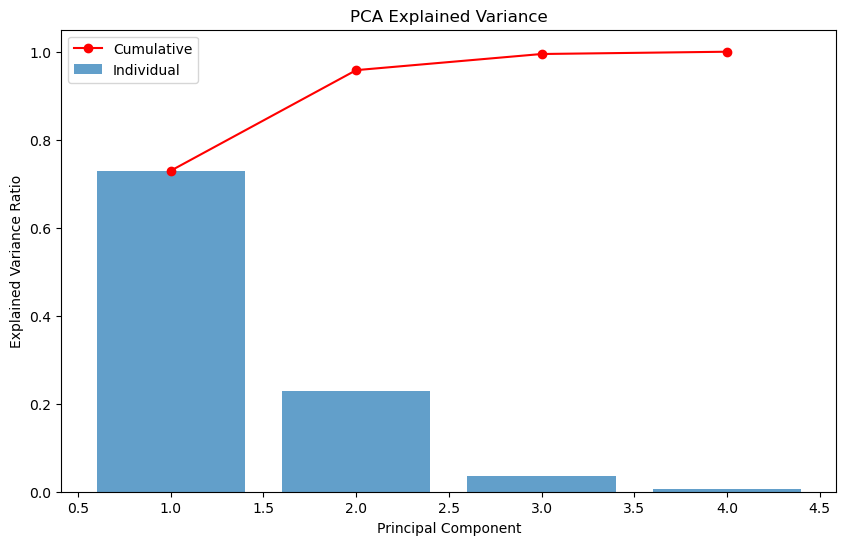

In [2]:
# Standardize first (PCA needs scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance:", np.cumsum(pca.explained_variance_ratio_))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, 5), pca.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

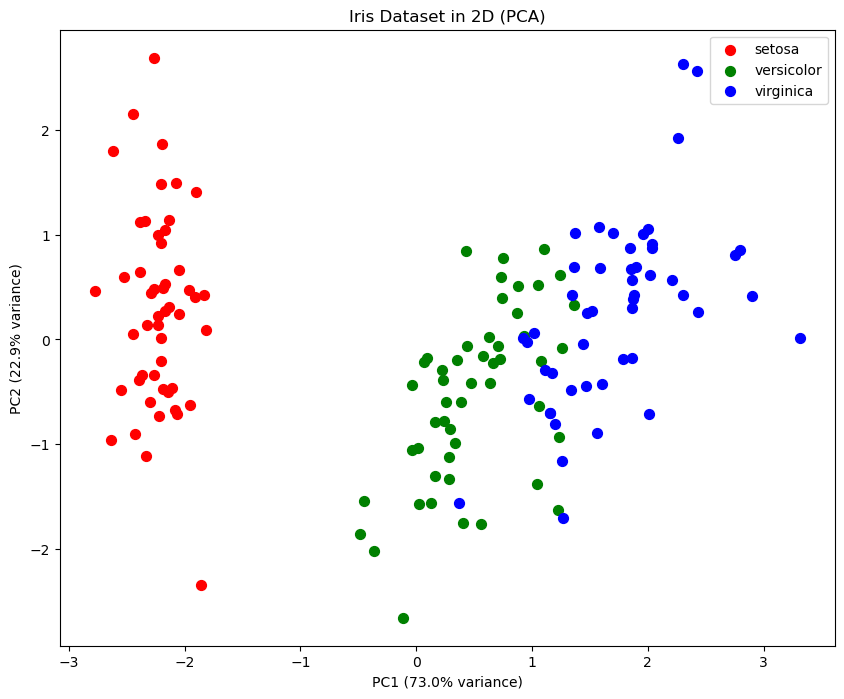

2 components explain 95.8% of variance!


In [3]:
# Reduce to 2D for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(X_2d[y == i, 0], X_2d[y == i, 1], 
                c=colors[i], label=iris.target_names[i], s=50)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Iris Dataset in 2D (PCA)')
plt.legend()
plt.show()

print(f"2 components explain {sum(pca_2d.explained_variance_ratio_):.1%} of variance!")